In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cloudprompts.evaluation import evaluate_segmentation

/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/cpenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks")
PRED_DIR = Path("../inference/clipseg_cloudsen12plus_lora/masks")
RUN_ROOT = Path("../inference/clipseg_cloudsen12plus_lora")

print("GT_DIR  :", GT_DIR, "exists:", GT_DIR.exists())
print("PRED_DIR:", PRED_DIR, "exists:", PRED_DIR.exists())
print("RUN_ROOT:", RUN_ROOT, "exists:", RUN_ROOT.exists())

GT_DIR  : ../data/cloudsen12plus/export_p509_high_npz/test/masks exists: True
PRED_DIR: ../inference/clipseg_cloudsen12plus_lora/masks exists: True
RUN_ROOT: ../inference/clipseg_cloudsen12plus_lora exists: True


In [3]:
def peek_npz(dirpath: Path, n=5):
    files = sorted(dirpath.glob("*.npz"))
    print(f"\n{dirpath} (npz={len(files)})")
    for p in files[:n]:
        z = np.load(p)
        print(" ", p.name, "keys:", z.files)

peek_npz(GT_DIR)
peek_npz(PRED_DIR)

gt_stems = {p.stem for p in GT_DIR.glob("*.npz")}
pr_stems = {p.stem for p in PRED_DIR.glob("*.npz")}
common = gt_stems & pr_stems
print(f"\nGT={len(gt_stems)}  Pred={len(pr_stems)}  Matched={len(common)}")
print("Example matches:", sorted(list(common))[:10])


../data/cloudsen12plus/export_p509_high_npz/test/masks (npz=975)
  ROI_0001__20190212T142031_20190212T143214_T19FDF.npz keys: ['mask']
  ROI_0001__20190304T142031_20190304T142654_T19FDF.npz keys: ['mask']
  ROI_0001__20190316T141049_20190316T142437_T19FDF.npz keys: ['mask']
  ROI_0001__20190525T141059_20190525T142053_T19FDF.npz keys: ['mask']
  ROI_0001__20200308T141731_20200308T143551_T19FDF.npz keys: ['mask']

../inference/clipseg_cloudsen12plus_lora/masks (npz=975)
  ROI_0001__20190212T142031_20190212T143214_T19FDF.npz keys: ['mask']
  ROI_0001__20190304T142031_20190304T142654_T19FDF.npz keys: ['mask']
  ROI_0001__20190316T141049_20190316T142437_T19FDF.npz keys: ['mask']
  ROI_0001__20190525T141059_20190525T142053_T19FDF.npz keys: ['mask']
  ROI_0001__20200308T141731_20200308T143551_T19FDF.npz keys: ['mask']

GT=975  Pred=975  Matched=975
Example matches: ['ROI_0001__20190212T142031_20190212T143214_T19FDF', 'ROI_0001__20190304T142031_20190304T142654_T19FDF', 'ROI_0001__20190316T141

In [7]:
NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

result = evaluate_segmentation(
    gt_dir=GT_DIR,
    pred_dir=PRED_DIR,
    model="clipseg",
    dataset="cloudsen12plus",
    stage="lora_eval",
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    run_root=RUN_ROOT,
    gt_key="mask",
    pred_key="mask",
    gt_ext=".npz",
    pred_ext=".npz",
    ignore_index=None,
    strict=True,
)

result

/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


{'miou_csv': '../inference/clipseg_cloudsen12plus_lora/miou_clipseg_cloudsen12plus_lora_eval.csv',
 'cm_csv': '../inference/clipseg_cloudsen12plus_lora/cm_clipseg_cloudsen12plus_lora_eval.csv',
 'num_samples': 975,
 'aggregate_miou': 0.5991315104337002,
 'aggregate_pixel_acc': 0.8385149833483574}

In [8]:
miou_df = pd.read_csv(result["miou_csv"])
cm_df   = pd.read_csv(result["cm_csv"])

display(miou_df.head())

,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
0,ROI_0001__20190212T142031_20190212T143214_T19FDF,0.516004,0.743481,0.707409,NaN,0.324598,NaN
1,ROI_0001__20190304T142031_20190304T142654_T19FDF,0.225636,0.230438,0.046997,0.773977,0.000000,0.081570
2,ROI_0001__20190316T141049_20190316T142437_T19FDF,0.487255,0.727459,0.666926,0.659167,0.000000,0.622929
3,ROI_0001__20190525T141059_20190525T142053_T19FDF,0.527044,0.753620,0.709049,0.705237,0.483790,0.210099
4,ROI_0001__20200308T141731_20200308T143551_T19FDF,1.000000,1.000000,1.000000,NaN,NaN,NaN


Images: 975 | GT: 975 | Pred: 975 | Matched: 975


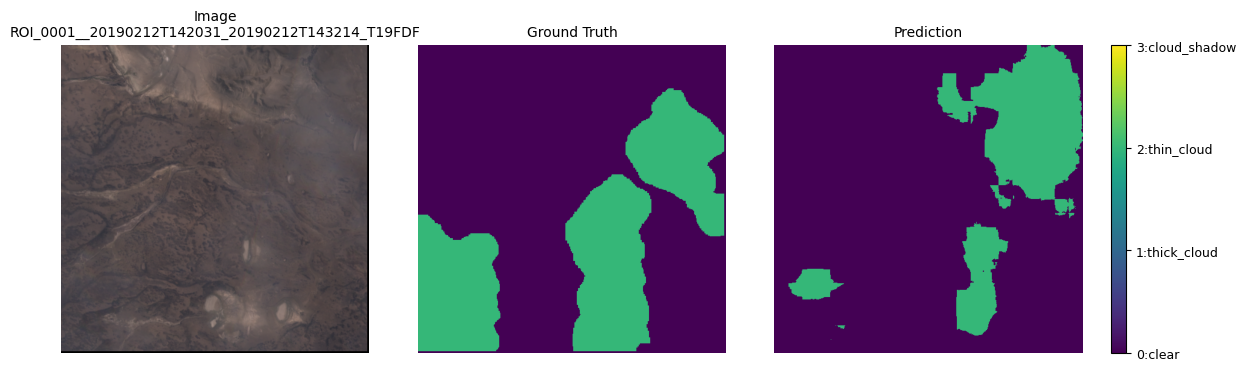

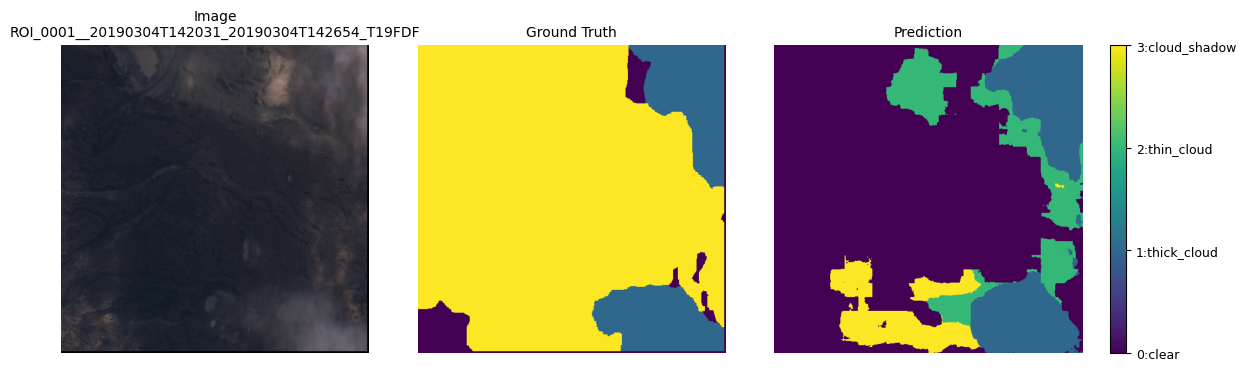

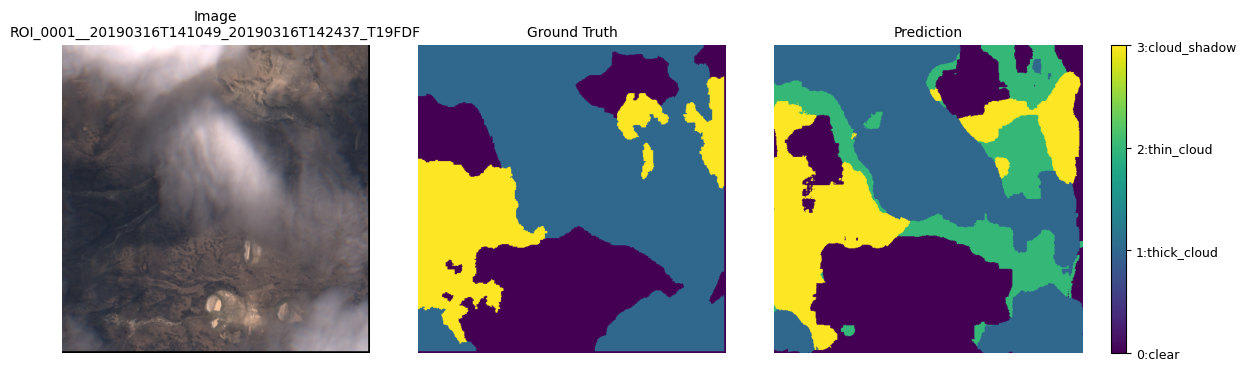

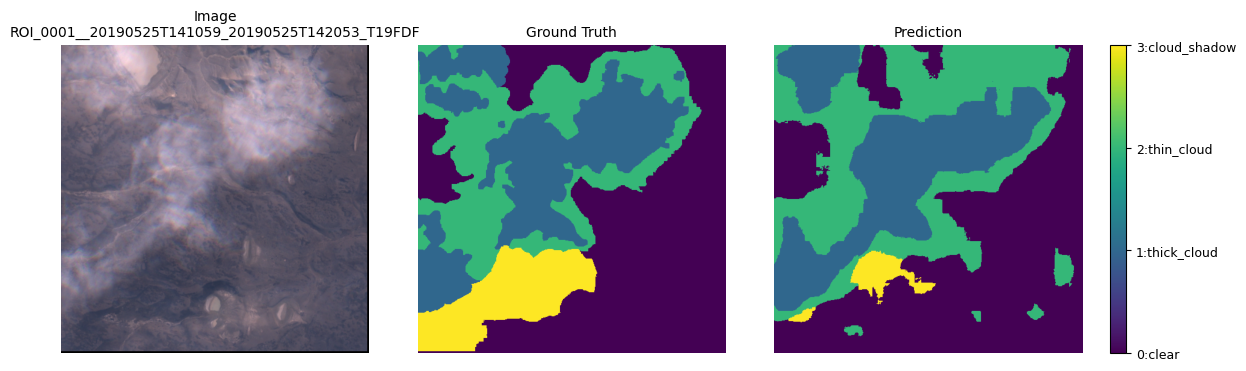

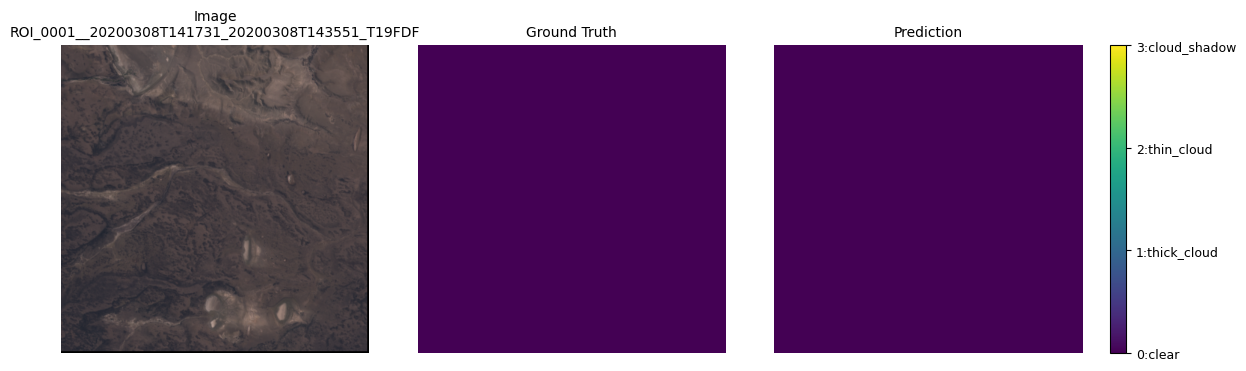

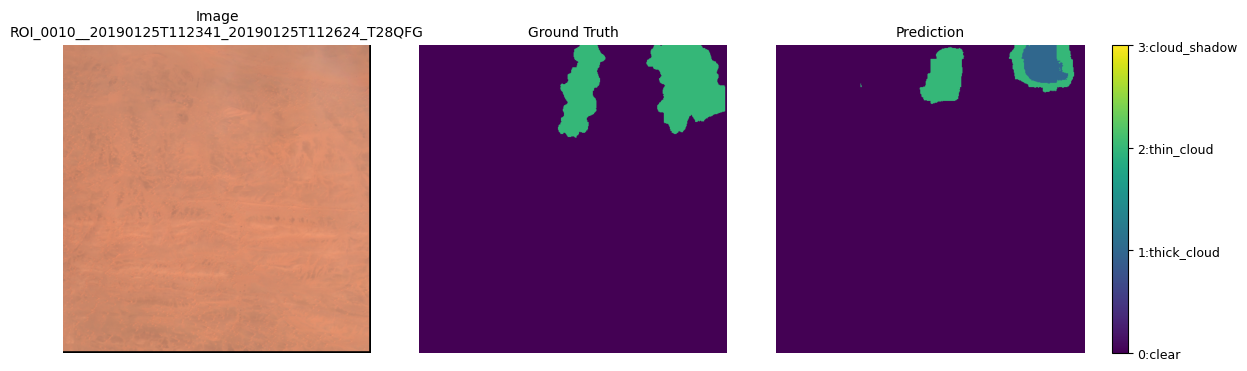

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMG_DIR  = Path("../data/cloudsen12plus/export_p509_high_npz/test/images")

NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

def load_rgb_from_npz(p: Path) -> np.ndarray:
    """Return HxWx3 uint8 RGB for plotting."""
    with np.load(p) as z:
        if "image" not in z.files:
            raise KeyError(f"{p.name}: expected key 'image', found {z.files}")
        arr = z["image"]
    if arr.ndim != 3 or arr.shape[0] != 3:
        raise ValueError(f"{p.name}: expected (3,H,W), got {arr.shape}")
    hwc = np.transpose(arr, (1,2,0))
    hwc = np.clip(hwc, 0.0, 1.0)
    return (hwc * 255.0).round().astype(np.uint8)

def load_mask_from_npz(p: Path) -> np.ndarray:
    with np.load(p) as z:
        if "mask" not in z.files:
            raise KeyError(f"{p.name}: expected key 'mask', found {z.files}")
        m = z["mask"]
    return m.astype(np.int64)

img_map  = {p.stem: p for p in IMG_DIR.glob("*.npz")}
gt_map   = {p.stem: p for p in GT_DIR.glob("*.npz")}
pred_map = {p.stem: p for p in PRED_DIR.glob("*.npz")}

common = sorted(set(img_map) & set(gt_map) & set(pred_map))
print(f"Images: {len(img_map)} | GT: {len(gt_map)} | Pred: {len(pred_map)} | Matched: {len(common)}")


START = 0
MAX_SHOW = 6
PAUSE = True

for i, stem in enumerate(common[START:START+MAX_SHOW], start=START):
    rgb = load_rgb_from_npz(img_map[stem])
    gt  = load_mask_from_npz(gt_map[stem])
    pr  = load_mask_from_npz(pred_map[stem])

    if gt.shape != pr.shape:
        print(f"[{i}] {stem}: shape mismatch gt={gt.shape}, pred={pr.shape}")
        continue

    fig, axes = plt.subplots(
        1, 4,
        figsize=(14, 4),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.045]},
    )

    ax_img, ax_gt, ax_pr, cax = axes

    fig.subplots_adjust(wspace=0.03)

    ax_img.imshow(rgb)
    ax_img.set_title(f"Image\n{stem}", fontsize=10)
    ax_img.axis("off")

    im_gt = ax_gt.imshow(gt, vmin=0, vmax=NUM_CLASSES-1)
    ax_gt.set_title("Ground Truth", fontsize=10)
    ax_gt.axis("off")

    im_pr = ax_pr.imshow(pr, vmin=0, vmax=NUM_CLASSES-1)
    ax_pr.set_title("Prediction", fontsize=10)
    ax_pr.axis("off")

    cbar = fig.colorbar(im_pr, cax=cax)
    cbar.set_ticks(list(range(NUM_CLASSES)))
    cbar.set_ticklabels([f"{k}:{name}" for k, name in enumerate(CLASS_NAMES)])
    cbar.ax.tick_params(labelsize=9)

    plt.show()
